# İkinci El Otomobil Piyasası Hız Tahmini

Bu notebookta Türkiye ikinci el otomobil piyasasının işlem hacmi iki farklı perspektiften tahmin edilecektir:

1. Bir sonraki ayın toplam işlem hacmi hızı
2. Gelecek üç ayın toplam işlem hacmi hızı

Temel hacim değişkeni:

\[
V_t = \text{t ayındaki noter otomobil devir adedi}
\]

## Bir aylık hız targetı

\[
speed^{1m}_t =
\frac{V_t-V_{t-1}}
     {V_t+V_{t-1}}
\]

Bu target, t ayının toplam otomobil devir hacmini bir önceki ayla karşılaştırır.

- Target pozitifse aylık işlem hacmi yükselmiştir.
- Target negatifse aylık işlem hacmi düşmüştür.
- Target sıfıra yakınsa hacim büyük ölçüde sabit kalmıştır.
- Targetın mutlak değeri büyüdükçe hareket kuvvetlenir.

Model, karar ayı t itibarıyla:

\[
speed^{1m}_{t+1}
\]

değerini tahmin edecektir.

## Üç aylık toplam hız targetı

Önce, bitiş ayı t olan üç aylık toplam hacim hesaplanır:

\[
Q_t = V_{t-2}+V_{t-1}+V_t
\]

Daha sonra bu toplam, hemen önceki ve onunla örtüşmeyen üç aylık toplamla karşılaştırılır:

\[
speed^{3m}_t =
\frac{Q_t-Q_{t-3}}
     {Q_t+Q_{t-3}}
\]

Burada:

\[
Q_{t-3}=V_{t-5}+V_{t-4}+V_{t-3}
\]

Karar ayı t itibarıyla tahmin edilmek istenen değer:

\[
speed^{3m}_{t+3}
\]

olacaktır. Bu değer aşağıdaki iki dönemi karşılaştırır:

\[
\text{Gelecek toplam}
=
V_{t+1}+V_{t+2}+V_{t+3}
\]

\[
\text{Geçmiş toplam}
=
V_{t-2}+V_{t-1}+V_t
\]

Dolayısıyla üç aylık target, “üç ay sonraki tek ayı” değil, gelecek üç ayın toplam işlem hacmini ölçer.

## Targetların ortak özellikleri

Her iki target da teorik olarak aşağıdaki aralıktadır:

\[
-1 < speed < 1
\]

- Pozitif değer piyasanın işlem hacmi bakımından hızlandığını,
- negatif değer piyasanın yavaşladığını,
- mutlak değerin büyümesi hareketin şiddetlendiğini gösterir.

Bu çalışmada:

- Yıllık veya geçen yılın aynı ayıyla karşılaştırılan target kullanılmayacaktır.
- Sınıflandırma yapılmayacaktır.
- İki hız serisi ayrı AutoGluon TimeSeries modelleriyle eğitilecektir.
- Bir aylık modelde `prediction_length=1` kullanılacaktır.
- Üç aylık toplam modelinde `prediction_length=3` kullanılacak ve karar çıktısı üçüncü tahmin adımı olacaktır.
- Modeller aynı rolling-origin test tarihleri üzerinde değerlendirilecektir.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Notebook proje ana klasöründeyse kullanılacak yol
data_path = Path(
    "data/noter_devir/noter_devir_2015_bugun_aylik.csv"
)

# Notebook "notebooks" klasöründeyse bir üst klasöre çık
if not data_path.exists():
    data_path = Path(
        "../data/noter_devir/noter_devir_2015_bugun_aylik.csv"
    )


# CSV dosyasını oku
df_raw = pd.read_csv(data_path)

# Yalnızca ihtiyacımız olan iki sütunu seç
df = df_raw[
    [
        "referans_ayi",
        "noter_devir_otomobil_adet",
    ]
].copy()

# YYYY-AA biçimindeki ay bilgisini gerçek tarih tipine dönüştür
df["referans_ayi"] = pd.to_datetime(
    df["referans_ayi"],
    format="%Y-%m",
)

# Otomobil devir sütununu sayısal tipe dönüştür
df["noter_devir_otomobil_adet"] = pd.to_numeric(
    df["noter_devir_otomobil_adet"],
    errors="coerce",
)

# Otomobile özgü noter verisi bulunmayan satırları çıkar
df = df.dropna(
    subset=["noter_devir_otomobil_adet"]
)

# Veriyi eskiden yeniye sırala ve satır indeksini yenile
df = (
    df.sort_values("referans_ayi")
    .reset_index(drop=True)
)

# Formülleri daha kolay okuyabilmek için hacim sütununa V adını ver
df = df.rename(
    columns={"noter_devir_otomobil_adet": "V"}
)

print("Dosya:", data_path.resolve())
print("Gözlem sayısı:", len(df))
print(
    "Tarih aralığı:",
    df["referans_ayi"].min().strftime("%Y-%m"),
    "→",
    df["referans_ayi"].max().strftime("%Y-%m"),
)

display(df.head())
display(df.tail())

Dosya: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2\data\noter_devir\noter_devir_2015_bugun_aylik.csv
Gözlem sayısı: 102
Tarih aralığı: 2018-01 → 2026-06


,referans_ayi,V
0,2018-01-01,"445,255.0000"
1,2018-02-01,"419,533.0000"
2,2018-03-01,"478,648.0000"
3,2018-04-01,"479,866.0000"
4,2018-05-01,"472,478.0000"


,referans_ayi,V
97,2026-02-01,"556,805.0000"
98,2026-03-01,"597,104.0000"
99,2026-04-01,"605,480.0000"
100,2026-05-01,"503,057.0000"
101,2026-06-01,"608,484.0000"


In [3]:
# Ham aylık veriyi korumak için yeni bir tablo oluştur
df_3ay = df.copy()

# Hacim serisini V değişkenine bağla
V = df_3ay["V"]

# Bitiş ayı t olan son üç aylık toplamı hesapla:
# Q_t = V_(t-2) + V_(t-1) + V_t
df_3ay["uc_aylik_toplam"] = (
    V.rolling(
        window=3,
        min_periods=3,
    )
    .sum()
)

# Son tamamlanan üç aylık toplamı,
# hemen önceki ve onunla örtüşmeyen üç aylık toplamla karşılaştır
df_3ay["target_3ay_hiz"] = (
    100
    * np.log(
        df_3ay["uc_aylik_toplam"]
        / df_3ay["uc_aylik_toplam"].shift(3)
    )
)

# Logaritmik hızı tam yüzde değişime dönüştür
df_3ay["target_3ay_yuzde_degisim"] = (
    100
    * np.expm1(
        df_3ay["target_3ay_hiz"] / 100
    )
)

# Target hesaplanamayan başlangıç satırlarını çıkar
target_3ay_df = (
    df_3ay.dropna(
        subset=["target_3ay_hiz"]
    )
    .reset_index(drop=True)
)

# Sonuçları kontrol et
assert len(target_3ay_df) == 97, (
    f"97 target bekleniyordu, "
    f"{len(target_3ay_df)} target bulundu."
)

print(
    "Geçerli target sayısı:",
    len(target_3ay_df),
)

print(
    "Gerçekleşme dönemi:",
    target_3ay_df["referans_ayi"].min().strftime("%Y-%m"),
    "→",
    target_3ay_df["referans_ayi"].max().strftime("%Y-%m"),
)

display(
    target_3ay_df[
        [
            "referans_ayi",
            "V",
            "uc_aylik_toplam",
            "target_3ay_hiz",
            "target_3ay_yuzde_degisim",
        ]
    ].head(10)
)

Geçerli target sayısı: 97
Gerçekleşme dönemi: 2018-06 → 2026-06


,referans_ayi,V,uc_aylik_toplam,target_3ay_hiz,target_3ay_yuzde_degisim
0,2018-06-01,"443,151.0000","1,395,495.0000",3.8019,3.8751
1,2018-07-01,"541,226.0000","1,456,855.0000",5.5613,5.7188
2,2018-08-01,"429,606.0000","1,413,983.0000",-1.1957,-1.1886
3,2018-09-01,"438,784.0000","1,409,616.0000",1.0068,1.0119
4,2018-10-01,"432,074.0000","1,300,464.0000",-11.3559,-10.7348
5,2018-11-01,"427,626.0000","1,298,484.0000",-8.5213,-8.1683
6,2018-12-01,"435,240.0000","1,294,940.0000",-8.4853,-8.1353
7,2019-01-01,"357,926.0000","1,220,792.0000",-6.3221,-6.1264
8,2019-02-01,"375,577.0000","1,168,743.0000",-10.5269,-9.9917
9,2019-03-01,"456,674.0000","1,190,177.0000",-8.4362,-8.0902


In [4]:
V.shift(1)

0              NaN
1     445,255.0000
2     419,533.0000
3     478,648.0000
4     479,866.0000
          ...     
97    582,180.0000
98    556,805.0000
99    597,104.0000
100   605,480.0000
101   503,057.0000
Name: V, Length: 102, dtype: float64

In [5]:
V.shift(2)

0              NaN
1              NaN
2     445,255.0000
3     419,533.0000
4     478,648.0000
          ...     
97    798,616.0000
98    582,180.0000
99    556,805.0000
100   597,104.0000
101   605,480.0000
Name: V, Length: 102, dtype: float64

In [6]:
V.shift(-1)

0     419,533.0000
1     478,648.0000
2     479,866.0000
3     472,478.0000
4     443,151.0000
          ...     
97    597,104.0000
98    605,480.0000
99    503,057.0000
100   608,484.0000
101            NaN
Name: V, Length: 102, dtype: float64

In [7]:
V.shift(-3)

0     479,866.0000
1     472,478.0000
2     443,151.0000
3     541,226.0000
4     429,606.0000
          ...     
97    503,057.0000
98    608,484.0000
99             NaN
100            NaN
101            NaN
Name: V, Length: 102, dtype: float64

In [8]:
uc_aylik_toplam = V.rolling(3).sum()

target_3ay_hiz = 100 * np.log(
    uc_aylik_toplam / uc_aylik_toplam.shift(3)
)

In [9]:
# Ham aylık veriyi korumak için yeni bir tablo oluştur
df_1ay = df.copy()

# Hacim serisini kısa bir değişken adına bağla
V = df_1ay["V"]

# Bir aylık logaritmik hacim hızını hesapla
df_1ay["target_1ay_hiz"] = (
    100
    * np.log(
        V / V.shift(1)
    )
)

# Logaritmik targetı tam yüzde değişime dönüştür
df_1ay["target_1ay_yuzde_degisim"] = (
    100
    * np.expm1(
        df_1ay["target_1ay_hiz"] / 100
    )
)

# İlk ayda önceki ay bulunmadığı için oluşan boş satırı çıkar
target_1ay_df = (
    df_1ay.dropna(
        subset=["target_1ay_hiz"]
    )
    .reset_index(drop=True)
)

# Gözlem sayısını kontrol et
assert len(target_1ay_df) == 101, (
    f"101 target bekleniyordu, "
    f"{len(target_1ay_df)} target bulundu."
)

print(
    "Geçerli target sayısı:",
    len(target_1ay_df),
)

print(
    "Gerçekleşme dönemi:",
    target_1ay_df["referans_ayi"].min().strftime("%Y-%m"),
    "→",
    target_1ay_df["referans_ayi"].max().strftime("%Y-%m"),
)

display(
    target_1ay_df[
        [
            "referans_ayi",
            "V",
            "target_1ay_hiz",
            "target_1ay_yuzde_degisim",
        ]
    ].head(10)
)

Geçerli target sayısı: 101
Gerçekleşme dönemi: 2018-02 → 2026-06


,referans_ayi,V,target_1ay_hiz,target_1ay_yuzde_degisim
0,2018-02-01,"419,533.0000",-5.9505,-5.7769
1,2018-03-01,"478,648.0000",13.1823,14.0907
2,2018-04-01,"479,866.0000",0.2541,0.2545
3,2018-05-01,"472,478.0000",-1.5516,-1.5396
4,2018-06-01,"443,151.0000",-6.4081,-6.2071
5,2018-07-01,"541,226.0000",19.9926,22.1313
6,2018-08-01,"429,606.0000",-23.0968,-20.6235
7,2018-09-01,"438,784.0000",2.1139,2.1364
8,2018-10-01,"432,074.0000",-1.5410,-1.5292
9,2018-11-01,"427,626.0000",-1.0348,-1.0295


,count,mean,std,min,25%,50%,75%,max,pozitif_sayi,negatif_sayi,sifir_sayi
target_1ay_hiz,101.0000,0.3092,22.5163,-77.1805,-11.8904,0.6837,10.7384,70.5959,53,48,0
target_3ay_hiz,97.0000,0.6858,22.5788,-57.8626,-10.5269,1.7719,16.4136,62.4990,51,46,0


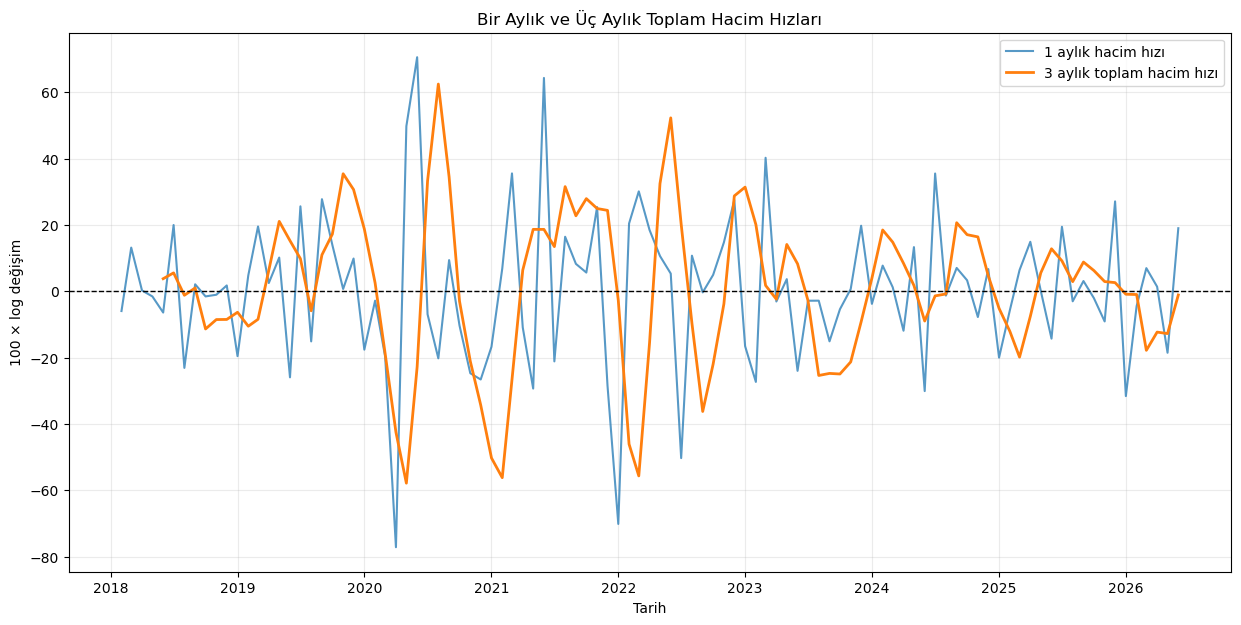

In [10]:
# İki targetı tarih üzerinde bir araya getir
target_karsilastirma = df[
    [
        "referans_ayi",
        "V",
    ]
].copy()

target_karsilastirma["target_1ay_hiz"] = (
    df_1ay["target_1ay_hiz"]
)

target_karsilastirma["target_3ay_hiz"] = (
    df_3ay["target_3ay_hiz"]
)

# Temel istatistikleri hesapla
target_ozet = target_karsilastirma[
    [
        "target_1ay_hiz",
        "target_3ay_hiz",
    ]
].describe().T

# Pozitif ve negatif target sayılarını ekle
target_ozet["pozitif_sayi"] = [
    (target_karsilastirma["target_1ay_hiz"] > 0).sum(),
    (target_karsilastirma["target_3ay_hiz"] > 0).sum(),
]

target_ozet["negatif_sayi"] = [
    (target_karsilastirma["target_1ay_hiz"] < 0).sum(),
    (target_karsilastirma["target_3ay_hiz"] < 0).sum(),
]

target_ozet["sifir_sayi"] = [
    (target_karsilastirma["target_1ay_hiz"] == 0).sum(),
    (target_karsilastirma["target_3ay_hiz"] == 0).sum(),
]

display(target_ozet)

# Targetları zaman boyunca çiz
fig, ax = plt.subplots(
    figsize=(15, 7)
)

ax.plot(
    target_karsilastirma["referans_ayi"],
    target_karsilastirma["target_1ay_hiz"],
    label="1 aylık hacim hızı",
    color="tab:blue",
    linewidth=1.5,
    alpha=0.75,
)

ax.plot(
    target_karsilastirma["referans_ayi"],
    target_karsilastirma["target_3ay_hiz"],
    label="3 aylık toplam hacim hızı",
    color="tab:orange",
    linewidth=2,
)

# Sıfır çizgisi yükseliş ve düşüşü ayırır
ax.axhline(
    y=0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Bir Aylık ve Üç Aylık Toplam Hacim Hızları"
)

ax.set_xlabel("Tarih")
ax.set_ylabel("100 × log değişim")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

In [11]:
try:
    import autogluon

    from autogluon.timeseries import (
        TimeSeriesDataFrame,
        TimeSeriesPredictor,
    )

    AUTOGLUON_KURULU = True

    print("AutoGluon başarıyla yüklendi.")
    print("AutoGluon sürümü:", autogluon.__version__)

except ImportError:
    AUTOGLUON_KURULU = False

    print("AutoGluon bu Python ortamında bulunamadı.")
    print("Önce AutoGluon kurulmalıdır.")

AutoGluon bu Python ortamında bulunamadı.
Önce AutoGluon kurulmalıdır.


In [15]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Modelin geçmişten kullanacağı ay sayısı
N_LAGS = 12

# İlk 60 aylık hacim gözlemi eğitim geçmişi olacak
FIRST_ORIGIN = 59

# Sonuçların kaydedileceği liste
hizli_test_sonuclari = []


def ozellik_uret(target_serisi, origin_index, horizon):
    """
    Belirli bir karar noktası için gecikmeli target değerleri
    ve hedef ayın takvim özelliklerini üretir.
    """

    # Son 12 target değerini al
    gecikmeler = [
        target_serisi.iloc[origin_index - lag]
        for lag in range(N_LAGS)
    ]

    # Tahmin edilecek ayı bul
    hedef_tarih = df.iloc[
        origin_index + horizon
    ]["referans_ayi"]

    # Ay numarasını döngüsel olarak temsil et
    ay_sin = np.sin(
        2 * np.pi * hedef_tarih.month / 12
    )

    ay_cos = np.cos(
        2 * np.pi * hedef_tarih.month / 12
    )

    return gecikmeler + [ay_sin, ay_cos]


def ridge_tahmin_et(
    target_serisi,
    origin_index,
    horizon,
):
    """
    Yalnız origin tarihine kadar bilinen verilerle
    Ridge modelini eğitir ve ileri tahmin üretir.
    """

    X_train = []
    y_train = []

    # Eğitim targetının origin tarihini geçmemesi gerekir.
    # Bu nedenle j + horizon <= origin_index olmalıdır.
    son_egitim_origini = (
        origin_index - horizon
    )

    for j in range(
        N_LAGS - 1,
        son_egitim_origini + 1,
    ):
        X_satiri = ozellik_uret(
            target_serisi,
            j,
            horizon,
        )

        y_degeri = target_serisi.iloc[
            j + horizon
        ]

        # Başlangıçtaki eksik targetları eğitimden çıkar
        if (
            np.isnan(X_satiri).any()
            or pd.isna(y_degeri)
        ):
            continue

        X_train.append(X_satiri)
        y_train.append(y_degeri)

    # Ölçekleme ve Ridge modelini tek işlem zincirinde birleştir
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=10.0),
    )

    # Modeli yalnız geçmiş gözlemlerle eğit
    model.fit(
        np.asarray(X_train),
        np.asarray(y_train),
    )

    # Güncel karar ayının özelliklerini üret
    X_tahmin = ozellik_uret(
        target_serisi,
        origin_index,
        horizon,
    )

    # İleri target tahminini üret
    tahmin = model.predict(
        np.asarray(X_tahmin).reshape(1, -1)
    )[0]

    # MASE için yıllık olmayan, bir önceki değere dayalı ölçek
    train_target = (
        target_serisi.iloc[: origin_index + 1]
        .dropna()
        .to_numpy()
    )

    mase_olcegi = np.mean(
        np.abs(
            np.diff(train_target)
        )
    )

    return tahmin, mase_olcegi, len(y_train)


# İki targetı aynı karar aylarında değerlendir
deneyler = [
    {
        "target_adi": "1 aylık hız",
        "target_serisi": target_karsilastirma[
            "target_1ay_hiz"
        ],
        "horizon": 1,
    },
    {
        "target_adi": "3 aylık toplam hız",
        "target_serisi": target_karsilastirma[
            "target_3ay_hiz"
        ],
        "horizon": 3,
    },
]


# Hem 1 hem 3 aylık gerçekleşmesi bilinen ortak karar ayları
for origin_index in range(
    FIRST_ORIGIN,
    len(df) - 3,
):
    for deney in deneyler:
        target_serisi = deney["target_serisi"]
        horizon = deney["horizon"]

        gercek_deger = target_serisi.iloc[
            origin_index + horizon
        ]

        ridge_tahmin, mase_olcegi, egitim_n = (
            ridge_tahmin_et(
                target_serisi=target_serisi,
                origin_index=origin_index,
                horizon=horizon,
            )
        )

        # Persistence baseline:
        # Gelecekteki hızın son gözlenen hıza eşit olduğunu varsayar.
        naive_tahmin = target_serisi.iloc[
            origin_index
        ]

        # Hareketsizlik baseline:
        # Gelecekteki hızın sıfır olacağını varsayar.
        sifir_tahmin = 0.0

        for model_adi, tahmin in [
            ("Ridge", ridge_tahmin),
            ("Son deger", naive_tahmin),
            ("Sifir hiz", sifir_tahmin),
        ]:
            hata = gercek_deger - tahmin

            hizli_test_sonuclari.append(
                {
                    "origin_tarihi": df.iloc[
                        origin_index
                    ]["referans_ayi"],
                    "target": deney["target_adi"],
                    "horizon": horizon,
                    "model": model_adi,
                    "gercek": gercek_deger,
                    "tahmin": tahmin,
                    "hata": hata,
                    "mutlak_hata": abs(hata),
                    "kare_hata": hata**2,
                    "mase_hata": (
                        abs(hata) / mase_olcegi
                    ),
                    "yon_dogru": (
                        np.sign(gercek_deger)
                        == np.sign(tahmin)
                    ),
                    "egitim_n": egitim_n,
                }
            )


# Sonuçları DataFrame'e dönüştür
hizli_test_df = pd.DataFrame(
    hizli_test_sonuclari
)


# Her target ve model için metrikleri hesapla
hizli_metrikler = (
    hizli_test_df
    .groupby(
        [
            "target",
            "horizon",
            "model",
        ]
    )
    .agg(
        gozlem=("gercek", "size"),
        MAE=("mutlak_hata", "mean"),
        RMSE=(
            "kare_hata",
            lambda x: np.sqrt(x.mean()),
        ),
        MASE=("mase_hata", "mean"),
        yon_dogrulugu=("yon_dogru", "mean"),
        bias=("hata", "mean"),
    )
    .reset_index()
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
)

display(hizli_metrikler)

,target,horizon,model,gozlem,MAE,RMSE,MASE,yon_dogrulugu,bias
1,1 aylık hız,1,Sifir hiz,40,11.5258,15.6722,0.4369,0.0000,-0.5824
0,1 aylık hız,1,Ridge,40,11.9890,16.9369,0.4490,0.6750,-0.5206
2,1 aylık hız,1,Son deger,40,20.9096,26.8750,0.7920,0.3500,-0.6539
4,3 aylık toplam hız,3,Sifir hiz,40,9.8465,12.3738,0.6501,0.0000,-0.7677
3,3 aylık toplam hız,3,Ridge,40,12.8036,18.6031,0.8106,0.5750,-0.8803
5,3 aylık toplam hız,3,Son deger,40,16.2818,19.8497,1.0721,0.4750,-2.6625


,target,horizon,model,gozlem,MAE,RMSE,MASE,yon_dogrulugu_yuzde,bias
1,1 aylık hız,1,Sifir hiz,40,11.5258,15.6722,0.4369,0.0000,-0.5824
0,1 aylık hız,1,Ridge,40,11.9890,16.9369,0.4490,67.5000,-0.5206
2,1 aylık hız,1,Son deger,40,20.9096,26.8750,0.7920,35.0000,-0.6539
4,3 aylık toplam hız,3,Sifir hiz,40,9.8465,12.3738,0.6501,0.0000,-0.7677
3,3 aylık toplam hız,3,Ridge,40,12.8036,18.6031,0.8106,57.5000,-0.8803
5,3 aylık toplam hız,3,Son deger,40,16.2818,19.8497,1.0721,47.5000,-2.6625


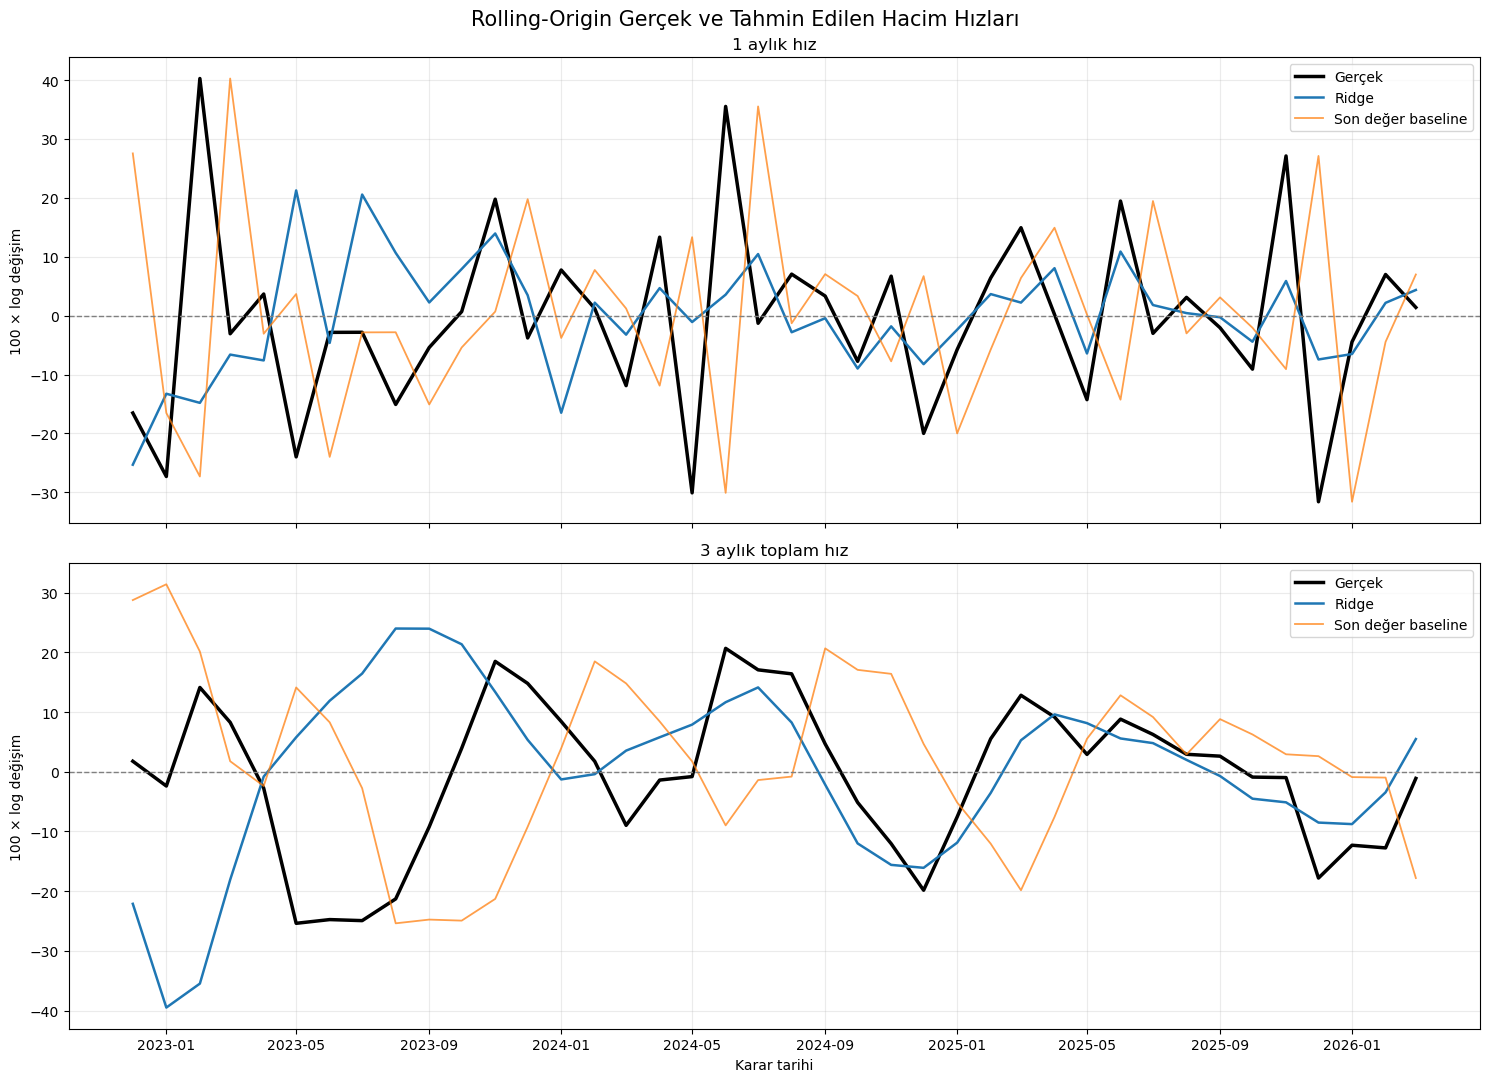

In [16]:
# Yön doğruluğunu yüzde biçimine dönüştür
gosterim_metrikleri = hizli_metrikler.copy()

gosterim_metrikleri["yon_dogrulugu_yuzde"] = (
    100
    * gosterim_metrikleri["yon_dogrulugu"]
)

# Daha okunabilir sütunları seç
display(
    gosterim_metrikleri[
        [
            "target",
            "horizon",
            "model",
            "gozlem",
            "MAE",
            "RMSE",
            "MASE",
            "yon_dogrulugu_yuzde",
            "bias",
        ]
    ]
)


# İki target için ayrı grafik alanı oluştur
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 11),
    sharex=True,
)

target_listesi = [
    "1 aylık hız",
    "3 aylık toplam hız",
]


for ax, target_adi in zip(
    axes,
    target_listesi,
):
    # Yalnız ilgili targetın sonuçlarını seç
    target_sonuclari = hizli_test_df[
        hizli_test_df["target"] == target_adi
    ].copy()

    # Gerçek değer her model için tekrarlandığı için
    # her karar tarihinden yalnız bir tanesini al
    gercek_seri = (
        target_sonuclari[
            [
                "origin_tarihi",
                "gercek",
            ]
        ]
        .drop_duplicates(
            subset=["origin_tarihi"]
        )
        .set_index("origin_tarihi")
        .sort_index()
    )

    # Model tahminlerini sütunlara dönüştür
    tahmin_tablosu = (
        target_sonuclari
        .pivot(
            index="origin_tarihi",
            columns="model",
            values="tahmin",
        )
        .sort_index()
    )

    # Gerçek targetı çiz
    ax.plot(
        gercek_seri.index,
        gercek_seri["gercek"],
        label="Gerçek",
        color="black",
        linewidth=2.5,
    )

    # Ridge tahminlerini çiz
    ax.plot(
        tahmin_tablosu.index,
        tahmin_tablosu["Ridge"],
        label="Ridge",
        color="tab:blue",
        linewidth=1.8,
    )

    # Son değer baseline tahminini çiz
    ax.plot(
        tahmin_tablosu.index,
        tahmin_tablosu["Son deger"],
        label="Son değer baseline",
        color="tab:orange",
        linewidth=1.3,
        alpha=0.75,
    )

    # Sıfır hız çizgisi
    ax.axhline(
        y=0,
        color="gray",
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(target_adi)
    ax.set_ylabel("100 × log değişim")
    ax.legend()
    ax.grid(alpha=0.25)


axes[-1].set_xlabel("Karar tarihi")

plt.suptitle(
    "Rolling-Origin Gerçek ve Tahmin Edilen Hacim Hızları",
    fontsize=15,
)

plt.tight_layout()
plt.show()

In [19]:
# Kronolojik dönem sınırları
TRAIN_END = pd.Timestamp("2022-12-01")

VALIDATION_START = pd.Timestamp("2022-12-01")
VALIDATION_END = pd.Timestamp("2024-03-01")

TEST_START = pd.Timestamp("2024-04-01")
TEST_END = pd.Timestamp("2026-03-01")


# Denenecek Ridge düzenlileştirme değerleri
ALPHA_ADAYLARI = [
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]


# Validasyon karar aylarının satır indeksleri
validation_origins = df.index[
    (
        df["referans_ayi"] >= VALIDATION_START
    )
    & (
        df["referans_ayi"] <= VALIDATION_END
    )
].tolist()


# Test karar aylarının satır indeksleri
test_origins = df.index[
    (
        df["referans_ayi"] >= TEST_START
    )
    & (
        df["referans_ayi"] <= TEST_END
    )
].tolist()


# İki ayrı modelleme deneyi
deneyler = [
    {
        "target_adi": "1 aylık hız",
        "target_serisi": target_karsilastirma[
            "target_1ay_hiz"
        ],
        "horizon": 1,
    },
    {
        "target_adi": "3 aylık toplam hız",
        "target_serisi": target_karsilastirma[
            "target_3ay_hiz"
        ],
        "horizon": 3,
    },
]


def belirli_alpha_ile_tahmin(
    target_serisi,
    origin_index,
    horizon,
    alpha,
):
    """
    Verilen alpha ile modeli yalnız origin tarihine kadar
    bilinen veriler üzerinde eğitir ve ileri tahmin üretir.
    """

    X_train = []
    y_train = []

    # Eğitim sonucunun origin tarihinde biliniyor olması gerekir
    son_egitim_origini = (
        origin_index - horizon
    )

    for j in range(
        N_LAGS - 1,
        son_egitim_origini + 1,
    ):
        X_satiri = ozellik_uret(
            target_serisi=target_serisi,
            origin_index=j,
            horizon=horizon,
        )

        y_degeri = target_serisi.iloc[
            j + horizon
        ]

        # Eksik başlangıç gözlemlerini kullanma
        if (
            np.isnan(X_satiri).any()
            or pd.isna(y_degeri)
        ):
            continue

        X_train.append(X_satiri)
        y_train.append(y_degeri)

    # Targetların yeterli eğitim verisine sahip olduğunu kontrol et
    if len(y_train) < 20:
        raise ValueError(
            f"Yetersiz eğitim gözlemi: {len(y_train)}"
        )

    # StandardScaler ve Ridge modelini birleştir
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha),
    )

    # Modeli geçmiş verilerle eğit
    model.fit(
        np.asarray(X_train),
        np.asarray(y_train),
    )

    # Karar ayındaki feature değerlerini oluştur
    X_tahmin = ozellik_uret(
        target_serisi=target_serisi,
        origin_index=origin_index,
        horizon=horizon,
    )

    # İleri tahmin üret
    tahmin = model.predict(
        np.asarray(X_tahmin).reshape(1, -1)
    )[0]

    # MASE için yalnız geçmiş targetlardan dönem-1 ölçeği hesapla
    train_target = (
        target_serisi.iloc[: origin_index + 1]
        .dropna()
        .to_numpy()
    )

    mase_olcegi = np.mean(
        np.abs(
            np.diff(train_target)
        )
    )

    return tahmin, mase_olcegi, len(y_train)


# --------------------------------------------------
# 1. VALIDASYON: En iyi alpha değerini seç
# --------------------------------------------------

validasyon_kayitlari = []


for deney in deneyler:
    target_adi = deney["target_adi"]
    target_serisi = deney["target_serisi"]
    horizon = deney["horizon"]

    for alpha in ALPHA_ADAYLARI:
        for origin_index in validation_origins:
            gercek = target_serisi.iloc[
                origin_index + horizon
            ]

            tahmin, _, egitim_n = (
                belirli_alpha_ile_tahmin(
                    target_serisi=target_serisi,
                    origin_index=origin_index,
                    horizon=horizon,
                    alpha=alpha,
                )
            )

            validasyon_kayitlari.append(
                {
                    "target": target_adi,
                    "horizon": horizon,
                    "alpha": alpha,
                    "origin_tarihi": df.iloc[
                        origin_index
                    ]["referans_ayi"],
                    "gercek": gercek,
                    "tahmin": tahmin,
                    "mutlak_hata": abs(
                        gercek - tahmin
                    ),
                    "egitim_n": egitim_n,
                }
            )


validasyon_df = pd.DataFrame(
    validasyon_kayitlari
)


# Her target ve alpha için ortalama validasyon hatası
validasyon_ozeti = (
    validasyon_df
    .groupby(
        [
            "target",
            "horizon",
            "alpha",
        ]
    )
    .agg(
        validasyon_gozlem=(
            "gercek",
            "size",
        ),
        validasyon_MAE=(
            "mutlak_hata",
            "mean",
        ),
    )
    .reset_index()
)


# Her target için en düşük validasyon MAE'sine sahip satırı bul
en_iyi_satirlar = (
    validasyon_ozeti
    .loc[
        validasyon_ozeti
        .groupby("target")[
            "validasyon_MAE"
        ]
        .idxmin()
    ]
    .reset_index(drop=True)
)


# Target → seçilen alpha sözlüğü
en_iyi_alpha = dict(
    zip(
        en_iyi_satirlar["target"],
        en_iyi_satirlar["alpha"],
    )
)


print("VALIDASYON SONUÇLARI")
display(validasyon_ozeti)

print("SEÇİLEN ALPHA DEĞERLERİ")
display(en_iyi_satirlar)


# --------------------------------------------------
# 2. TEST: Alpha artık değiştirilmeyecek
# --------------------------------------------------

test_kayitlari = []


for deney in deneyler:
    target_adi = deney["target_adi"]
    target_serisi = deney["target_serisi"]
    horizon = deney["horizon"]

    # Yalnız validasyonda seçilmiş alpha kullanılır
    secilen_alpha = en_iyi_alpha[
        target_adi
    ]

    for origin_index in test_origins:
        gercek = target_serisi.iloc[
            origin_index + horizon
        ]

        ridge_tahmin, mase_olcegi, egitim_n = (
            belirli_alpha_ile_tahmin(
                target_serisi=target_serisi,
                origin_index=origin_index,
                horizon=horizon,
                alpha=secilen_alpha,
            )
        )

        baseline_tahminleri = {
            "Ridge": ridge_tahmin,
            "Son değer": target_serisi.iloc[
                origin_index
            ],
            "Sıfır hız": 0.0,
        }

        for model_adi, tahmin in (
            baseline_tahminleri.items()
        ):
            hata = gercek - tahmin

            # Sıfır tahminin bir yön iddiası yoktur
            if tahmin == 0:
                yon_dogru = np.nan
            else:
                yon_dogru = (
                    np.sign(gercek)
                    == np.sign(tahmin)
                )

            test_kayitlari.append(
                {
                    "origin_tarihi": df.iloc[
                        origin_index
                    ]["referans_ayi"],
                    "target": target_adi,
                    "horizon": horizon,
                    "model": model_adi,
                    "alpha": secilen_alpha,
                    "gercek": gercek,
                    "tahmin": tahmin,
                    "hata": hata,
                    "mutlak_hata": abs(hata),
                    "kare_hata": hata**2,
                    "mase_hata": (
                        abs(hata) / mase_olcegi
                    ),
                    "yon_dogru": yon_dogru,
                    "egitim_n": egitim_n,
                }
            )


test_df = pd.DataFrame(
    test_kayitlari
)


# Nihai test metriklerini hesapla
test_metrikleri = (
    test_df
    .groupby(
        [
            "target",
            "horizon",
            "model",
            "alpha",
        ],
        dropna=False,
    )
    .agg(
        test_gozlem=("gercek", "size"),
        MAE=("mutlak_hata", "mean"),
        RMSE=(
            "kare_hata",
            lambda x: np.sqrt(x.mean()),
        ),
        MASE=("mase_hata", "mean"),
        yon_dogrulugu=(
            "yon_dogru",
            "mean",
        ),
        bias=("hata", "mean"),
    )
    .reset_index()
)


test_metrikleri[
    "yon_dogrulugu_yuzde"
] = (
    100
    * test_metrikleri[
        "yon_dogrulugu"
    ]
)


test_metrikleri = (
    test_metrikleri
    .sort_values(
        [
            "target",
            "MAE",
        ]
    )
    .reset_index(drop=True)
)


print("KRONOLOJİK AYRIM")
print(
    "Eğitim sonu:",
    TRAIN_END.strftime("%Y-%m"),
)
print(
    "Validasyon originleri:",
    VALIDATION_START.strftime("%Y-%m"),
    "→",
    VALIDATION_END.strftime("%Y-%m"),
    "| n =",
    len(validation_origins),
)
print(
    "Test originleri:",
    TEST_START.strftime("%Y-%m"),
    "→",
    TEST_END.strftime("%Y-%m"),
    "| n =",
    len(test_origins),
)

VALIDASYON SONUÇLARI


,target,horizon,alpha,validasyon_gozlem,validasyon_MAE
0,1 aylık hız,1,0.1000,16,20.2491
1,1 aylık hız,1,1.0000,16,19.3501
2,1 aylık hız,1,10.0000,16,15.6724
3,1 aylık hız,1,100.0000,16,12.3477
4,1 aylık hız,1,"1,000.0000",16,12.0081
5,3 aylık toplam hız,3,0.1000,16,30.2807
6,3 aylık toplam hız,3,1.0000,16,29.3761
7,3 aylık toplam hız,3,10.0000,16,23.9432
8,3 aylık toplam hız,3,100.0000,16,15.9172
9,3 aylık toplam hız,3,"1,000.0000",16,12.5844


SEÇİLEN ALPHA DEĞERLERİ


,target,horizon,alpha,validasyon_gozlem,validasyon_MAE
0,1 aylık hız,1,"1,000.0000",16,12.0081
1,3 aylık toplam hız,3,"1,000.0000",16,12.5844


KRONOLOJİK AYRIM
Eğitim sonu: 2022-12
Validasyon originleri: 2022-12 → 2024-03 | n = 16
Test originleri: 2024-04 → 2026-03 | n = 24


In [18]:
# Önce yön doğruluğu sütununu boş sayısal sütun olarak oluştur
test_df["yon_dogru_sayisal"] = np.nan

# Sıfır-hız modeli bir yükseliş veya düşüş iddiası taşımaz
yon_tahmini_yapanlar = (
    test_df["model"] != "Sıfır hız"
)

# Doğru yönü 1.0, yanlış yönü 0.0 olarak kaydet
test_df.loc[
    yon_tahmini_yapanlar,
    "yon_dogru_sayisal",
] = (
    np.sign(
        test_df.loc[
            yon_tahmini_yapanlar,
            "gercek",
        ].astype(float)
    )
    ==
    np.sign(
        test_df.loc[
            yon_tahmini_yapanlar,
            "tahmin",
        ].astype(float)
    )
).astype(float)


# Düzeltilmiş yön doğruluklarını hesapla
duzeltilmis_yon = (
    test_df
    .groupby(
        [
            "target",
            "horizon",
            "model",
        ]
    )
    .agg(
        yon_dogrulugu=(
            "yon_dogru_sayisal",
            "mean",
        ),
        dogru_yon_sayisi=(
            "yon_dogru_sayisal",
            "sum",
        ),
        yon_degerlendirme_sayisi=(
            "yon_dogru_sayisal",
            "count",
        ),
    )
    .reset_index()
)

duzeltilmis_yon[
    "yon_dogrulugu_yuzde"
] = (
    100
    * duzeltilmis_yon[
        "yon_dogrulugu"
    ]
)

display(duzeltilmis_yon)

,target,horizon,model,yon_dogrulugu,dogru_yon_sayisi,yon_degerlendirme_sayisi,yon_dogrulugu_yuzde
0,1 aylık hız,1,Ridge,0.6250,15.0000,24,62.5000
1,1 aylık hız,1,Son değer,0.2917,7.0000,24,29.1667
2,1 aylık hız,1,Sıfır hız,NaN,0.0000,0,NaN
3,3 aylık toplam hız,3,Ridge,0.6250,15.0000,24,62.5000
4,3 aylık toplam hız,3,Son değer,0.4167,10.0000,24,41.6667
5,3 aylık toplam hız,3,Sıfır hız,NaN,0.0000,0,NaN
